# This notebook analyzes historical weather time-series data and applies statistical and neural forecasting models.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import mplfinance as mpf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import boxcox
import math as m
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Input, Dense, SimpleRNN, LSTM
from IPython.display import display, Markdown

# 1. Exploratory Data Analysis (EDA)

In [83]:
# Load the weather data
df = pd.read_csv("./WeatherAnalysis.csv", index_col=0)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 648 entries, 01-10-2019 00:00 to nan
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature       499 non-null    float64
 1   humidity          499 non-null    float64
 2   dew_point         499 non-null    float64
 3   wind_bearing      499 non-null    float64
 4   wind_speed        499 non-null    float64
 5   wind_gust         499 non-null    float64
 6   pressure          499 non-null    float64
 7   uv_index          499 non-null    float64
 8   ozone             499 non-null    float64
 9   precip_intensity  499 non-null    float64
 10  icon              499 non-null    object 
dtypes: float64(10), object(1)
memory usage: 60.8+ KB


## 1.1 Description

### - The dataset contains 648 entries, and 499 of them are non-null.
### - The dataset shows the weather features within 24 hours for 21 days
### - The last day (21-10-2019) shows 18 hours (6 hours missing). For this reason the day will be dropped

### - Maybe we will use the time-series model to predict the last 6 hours of the 21st day

## 1.2 Cleaning the dataset

In [90]:
# Dropping null rows
cdf = df.dropna()
display(cdf.shape)

# Dropping the 21st day from the dataset (it has missing hours)
cdf = cdf.iloc[:480,:]
display(cdf.tail())

# Converting the time to datetime class and setting the frequency to hours
cdf.index = pd.to_datetime(cdf.index, dayfirst=True)
cdf.asfreq('h')
display(cdf.iloc[0])

(499, 11)

,temperature,humidity,dew_point,wind_bearing,wind_speed,wind_gust,pressure,uv_index,ozone,precip_intensity,icon
datetime_local,,,,,,,,,,,
20-10-2019 19:00,29.0,0.0,13.10,341.0,2.98,2.98,1013.58,0.0,277.2,0.0,clear-night
20-10-2019 20:00,27.0,0.0,13.17,338.0,2.53,2.65,1014.07,0.0,277.3,0.0,clear-night
20-10-2019 21:00,26.0,0.0,13.15,343.0,2.33,2.69,1014.22,0.0,277.4,0.0,clear-night
20-10-2019 22:00,25.0,0.0,13.04,357.0,2.37,2.85,1014.42,0.0,277.6,0.0,clear-night
20-10-2019 23:00,24.0,1.0,12.87,12.0,2.40,3.00,1014.47,0.0,277.7,0.0,clear-night


temperature                        26.0
humidity                            1.0
dew_point                         22.01
wind_bearing                      101.0
wind_speed                         3.08
wind_gust                          6.42
pressure                        1008.45
uv_index                            0.0
ozone                             268.6
precip_intensity                    0.0
icon                partly-cloudy-night
Name: 2019-10-01 00:00:00, dtype: object

## 1.3 Visualization

Text(0, 0.5, 'Dew Point')

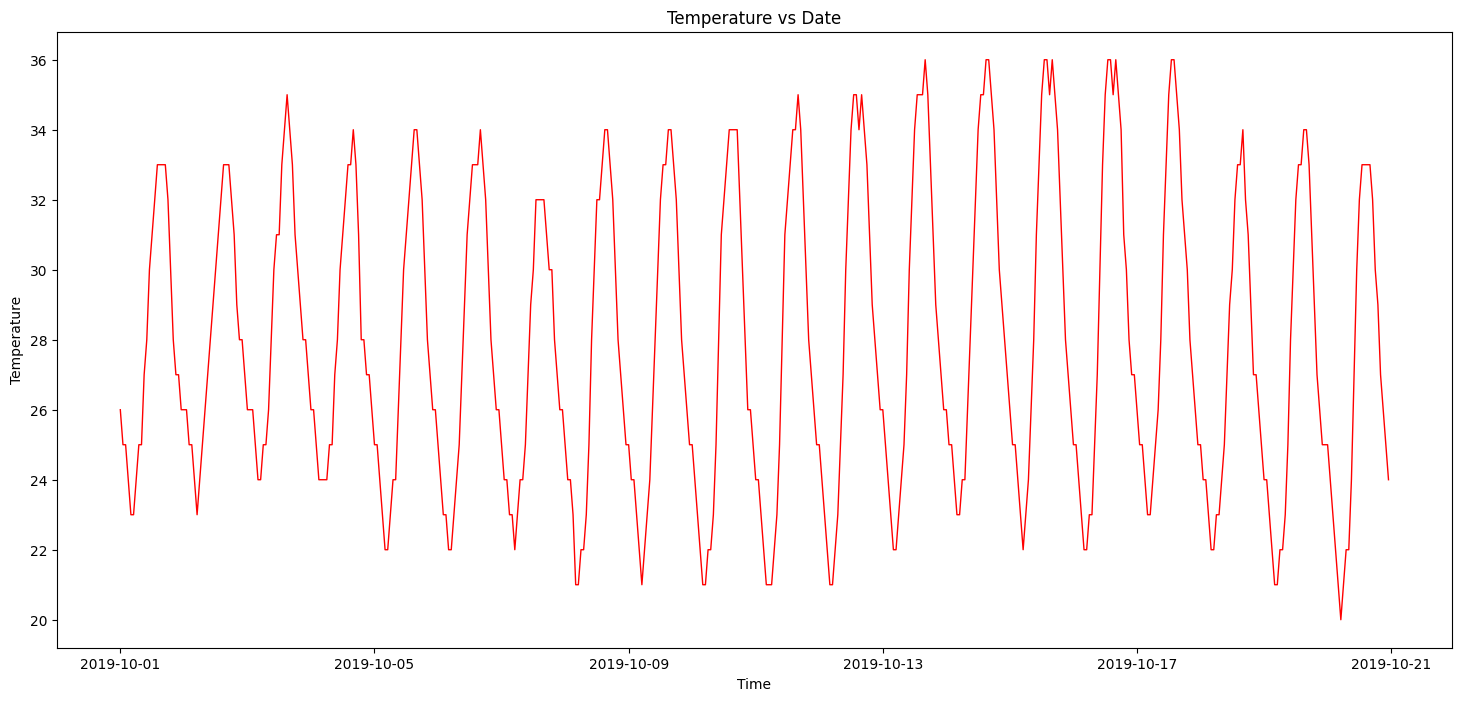

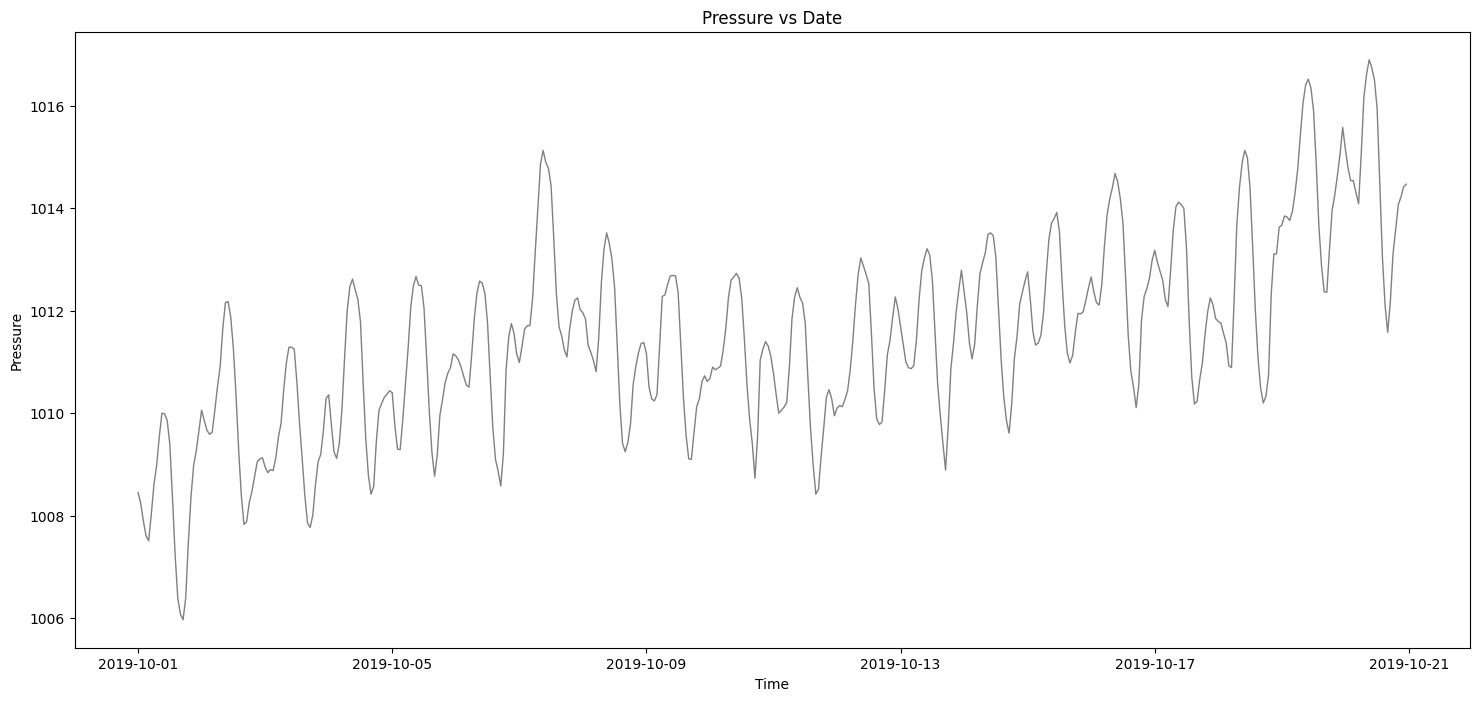

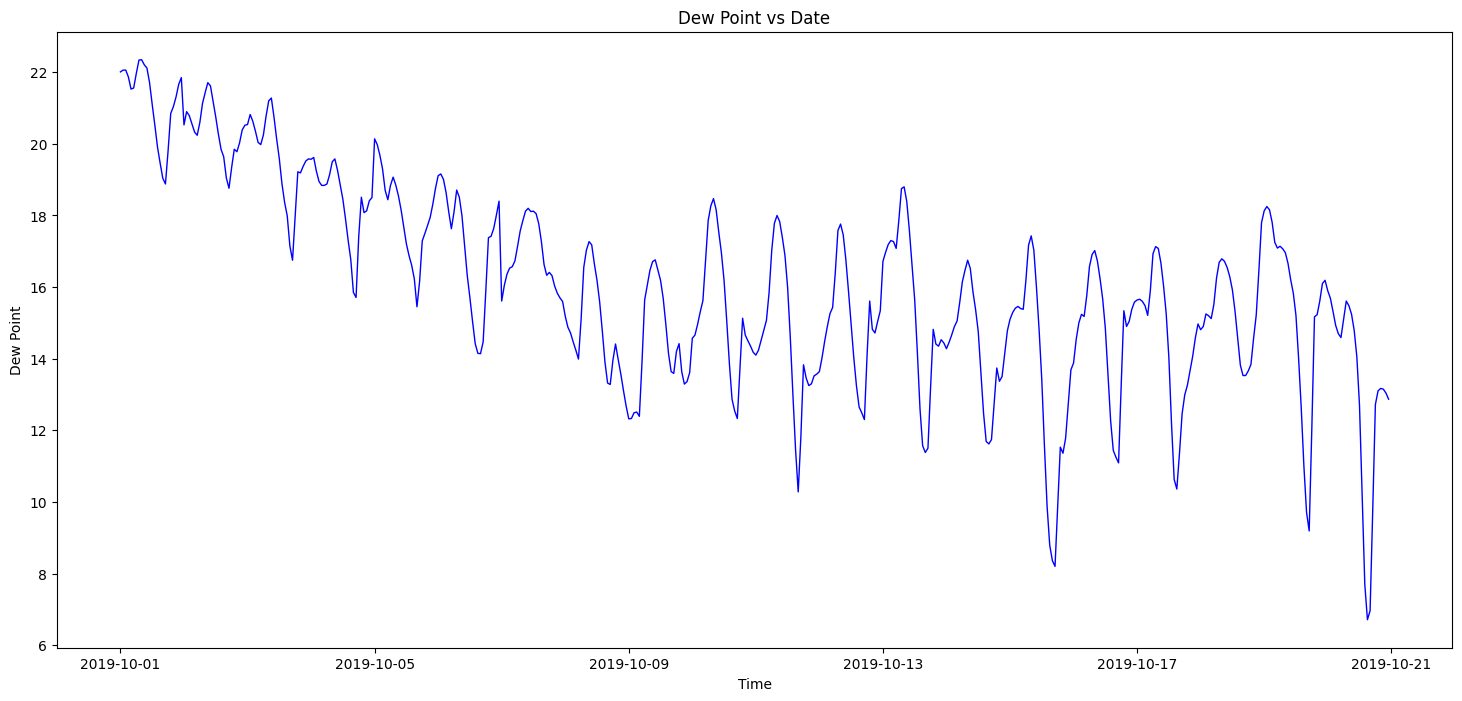

In [91]:
ts_temp = cdf.iloc[:,0].squeeze()

# Temperature vs Time
plt.figure(figsize=(18,8))
plt.plot(ts_temp, 'r-', linewidth=1)
plt.title('Temperature vs Date')
plt.xlabel('Time')
plt.ylabel('Temperature')


ts_pressure = cdf.iloc[:,6].squeeze()

# Pressure vs Time
plt.figure(figsize=(18,8))
plt.plot(ts_pressure, 'gray', linewidth=1)
plt.title('Pressure vs Date')
plt.xlabel('Time')
plt.ylabel('Pressure')


ts_dp = cdf.iloc[:,2].squeeze()

# Dew Point vs Time
plt.figure(figsize=(18,8))
plt.plot(ts_dp, '-b', linewidth=1)
plt.title('Dew Point vs Date')
plt.xlabel('Time')
plt.ylabel('Dew Point')

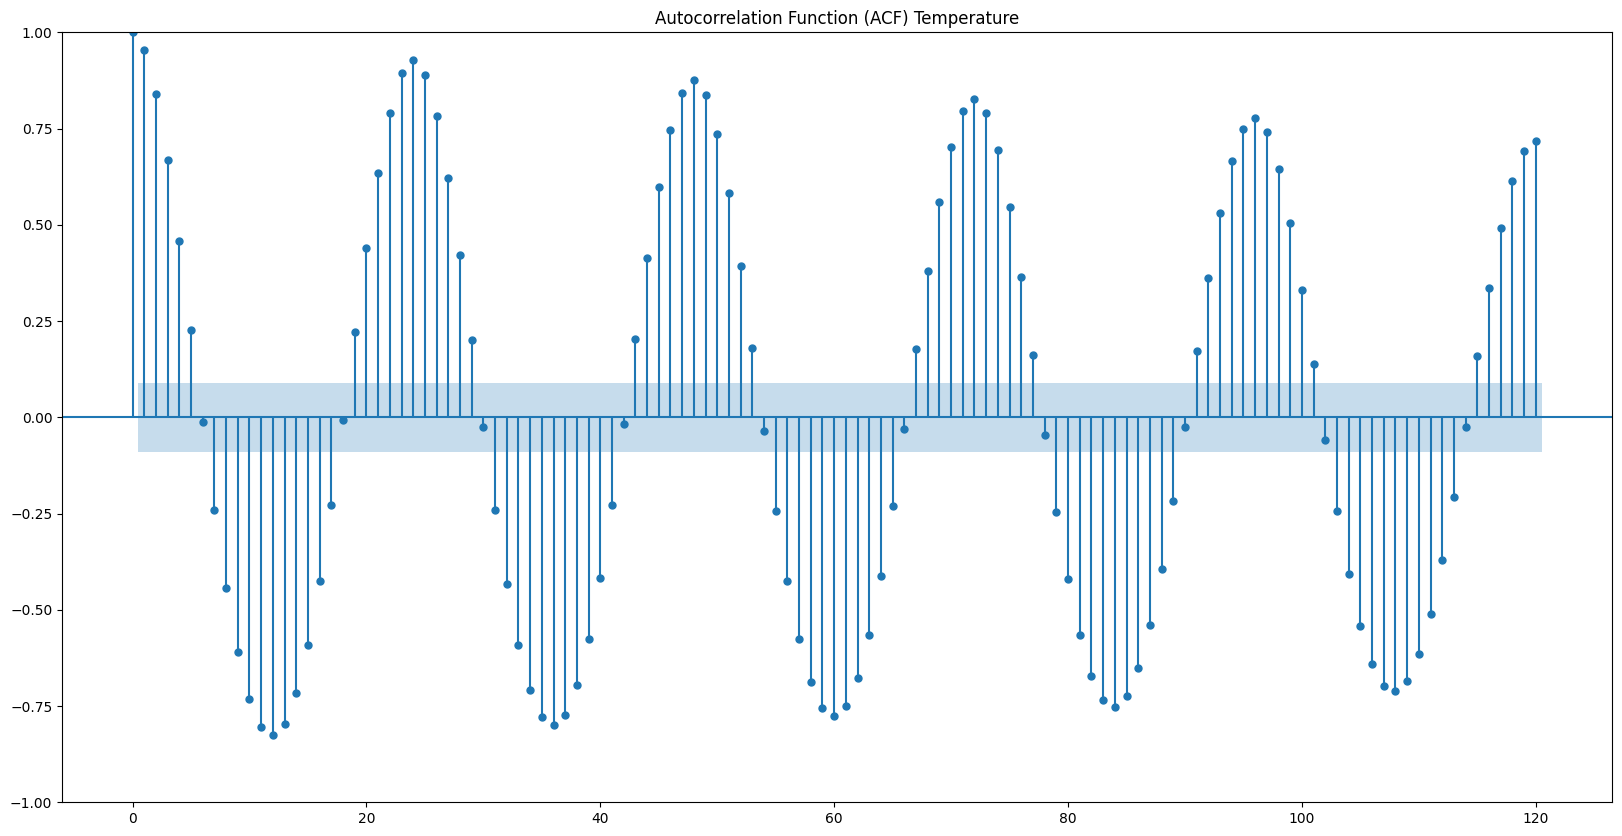

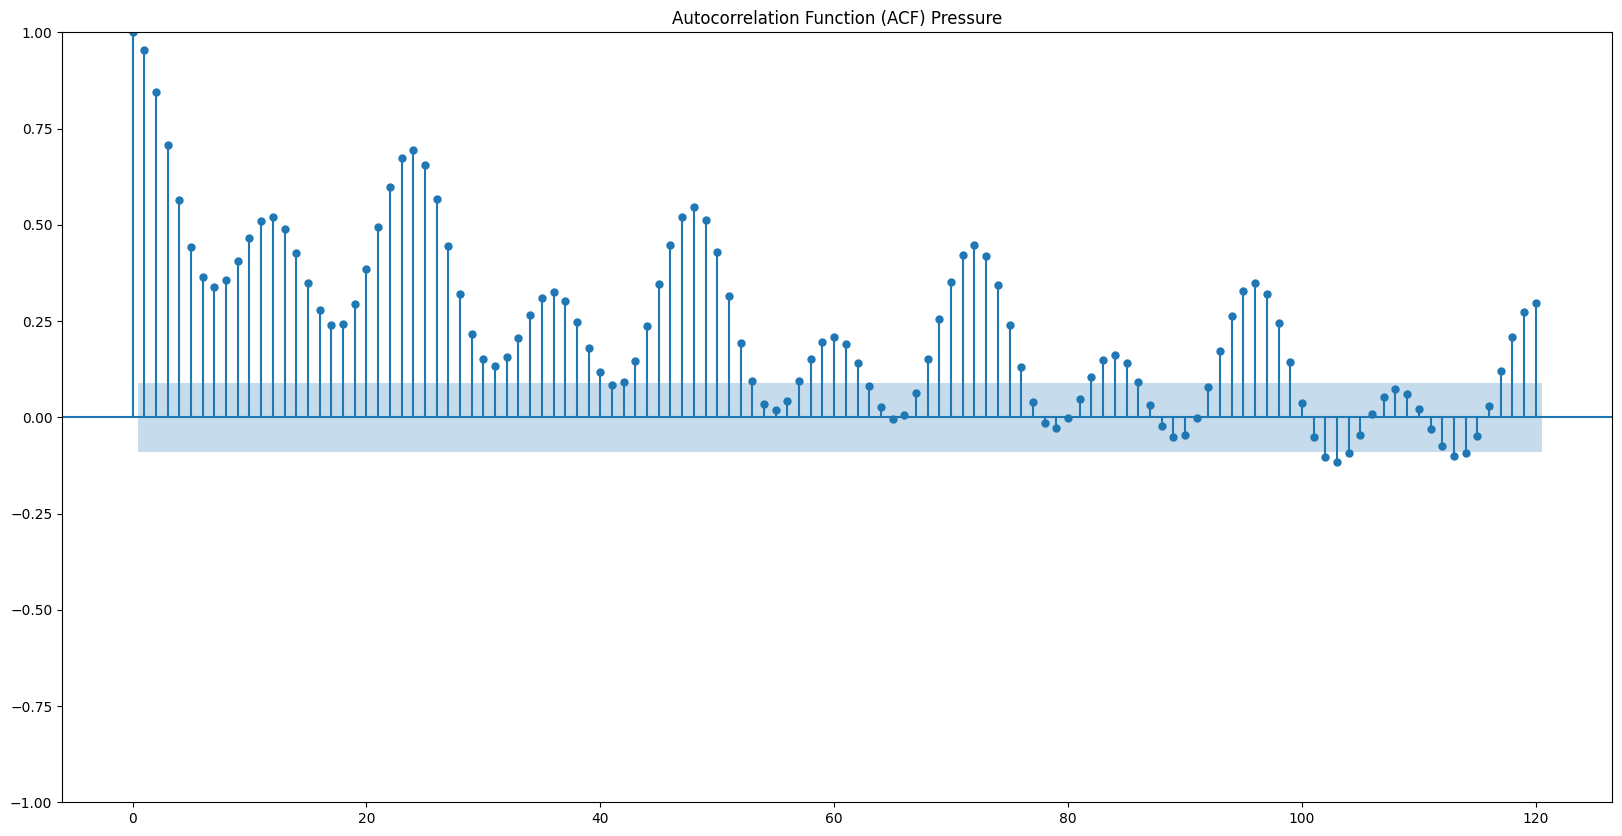

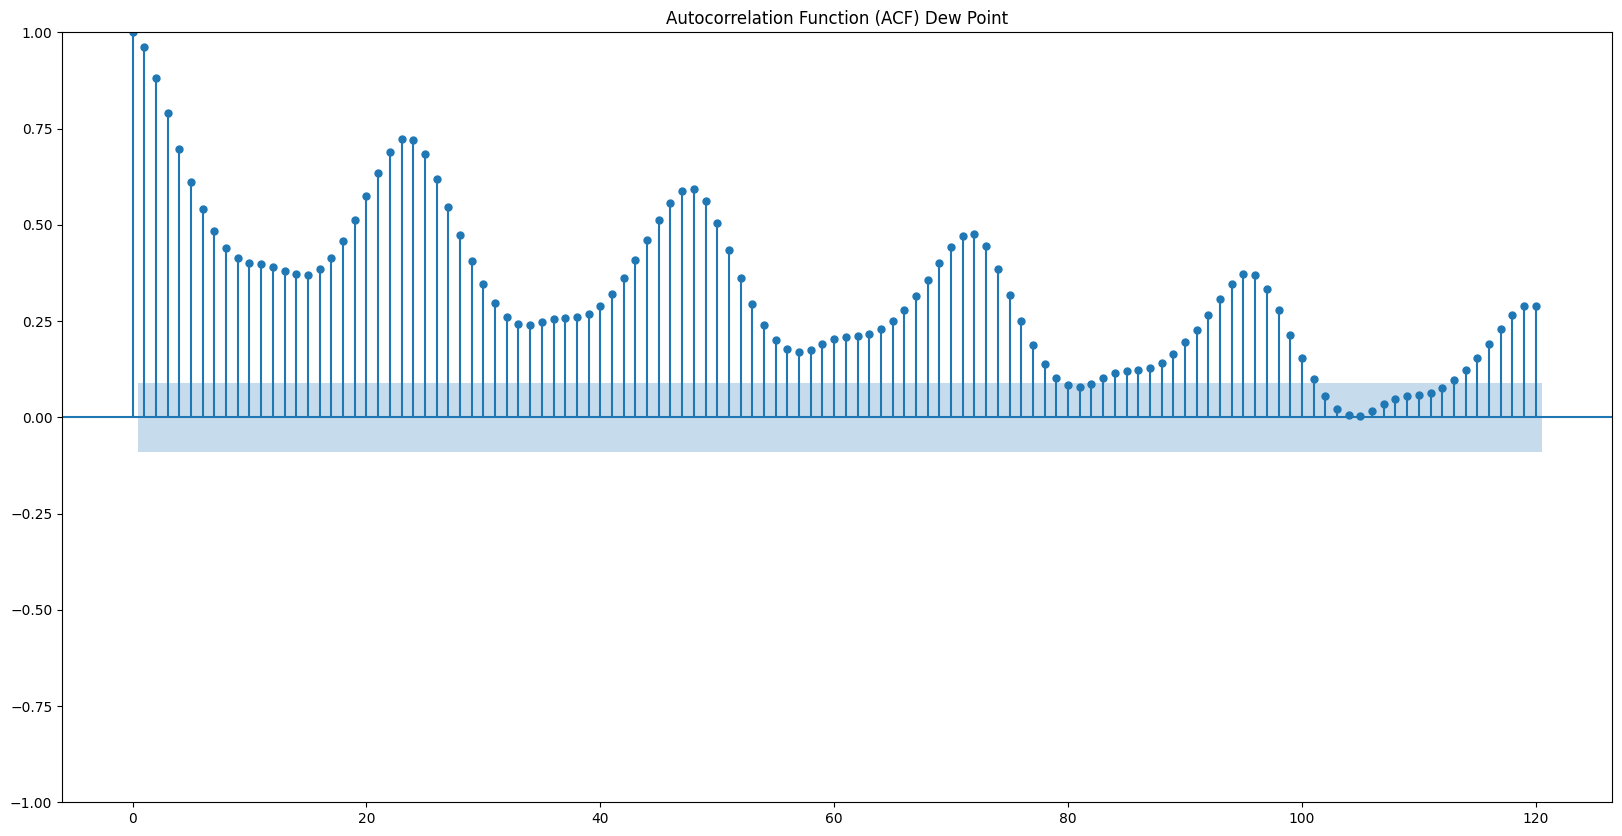

Variograms for the same time-series


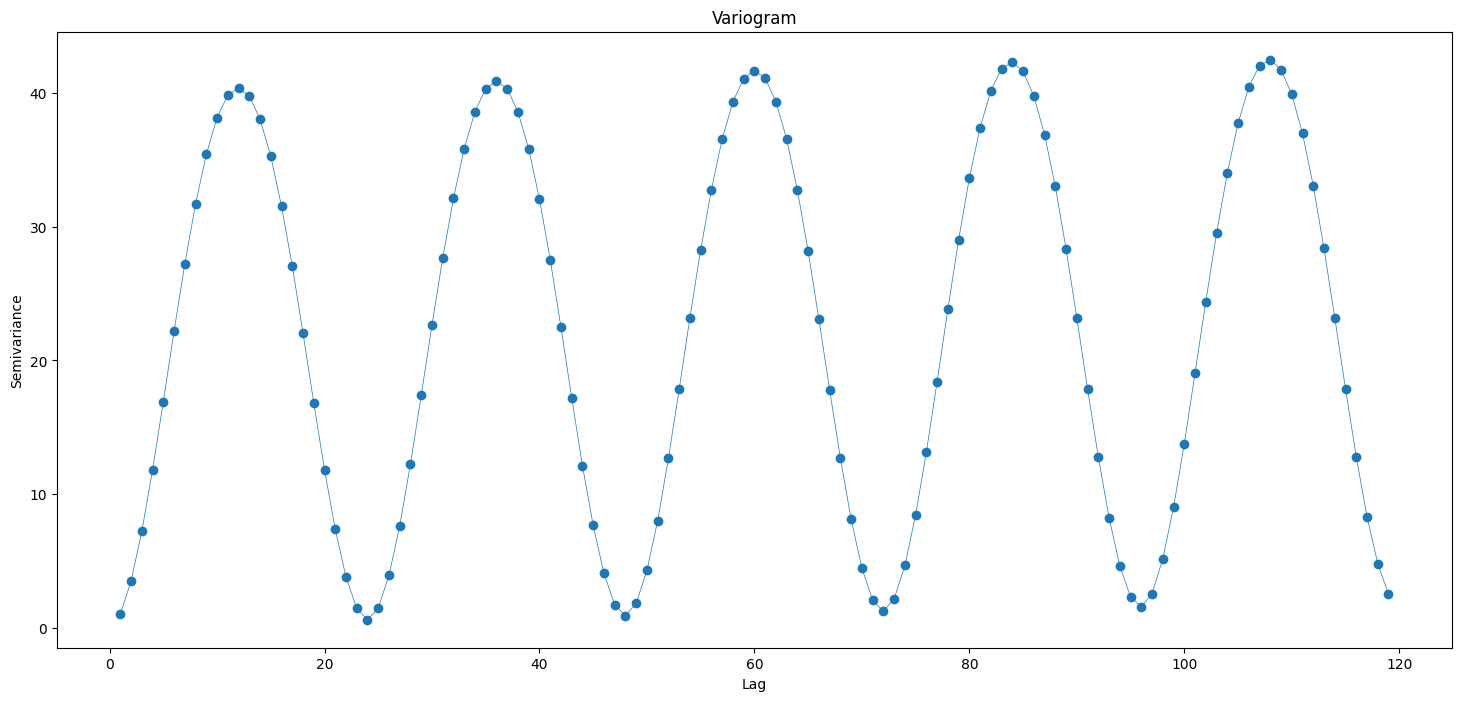

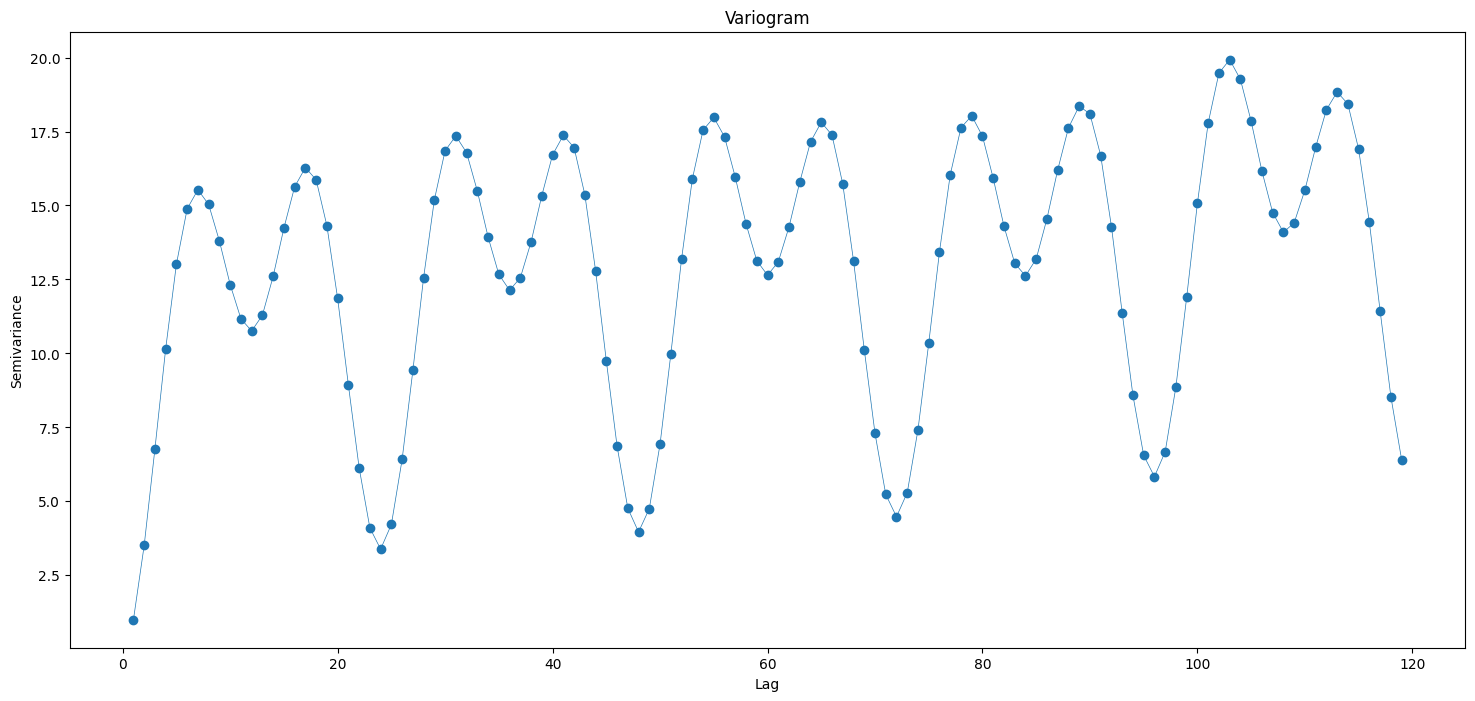

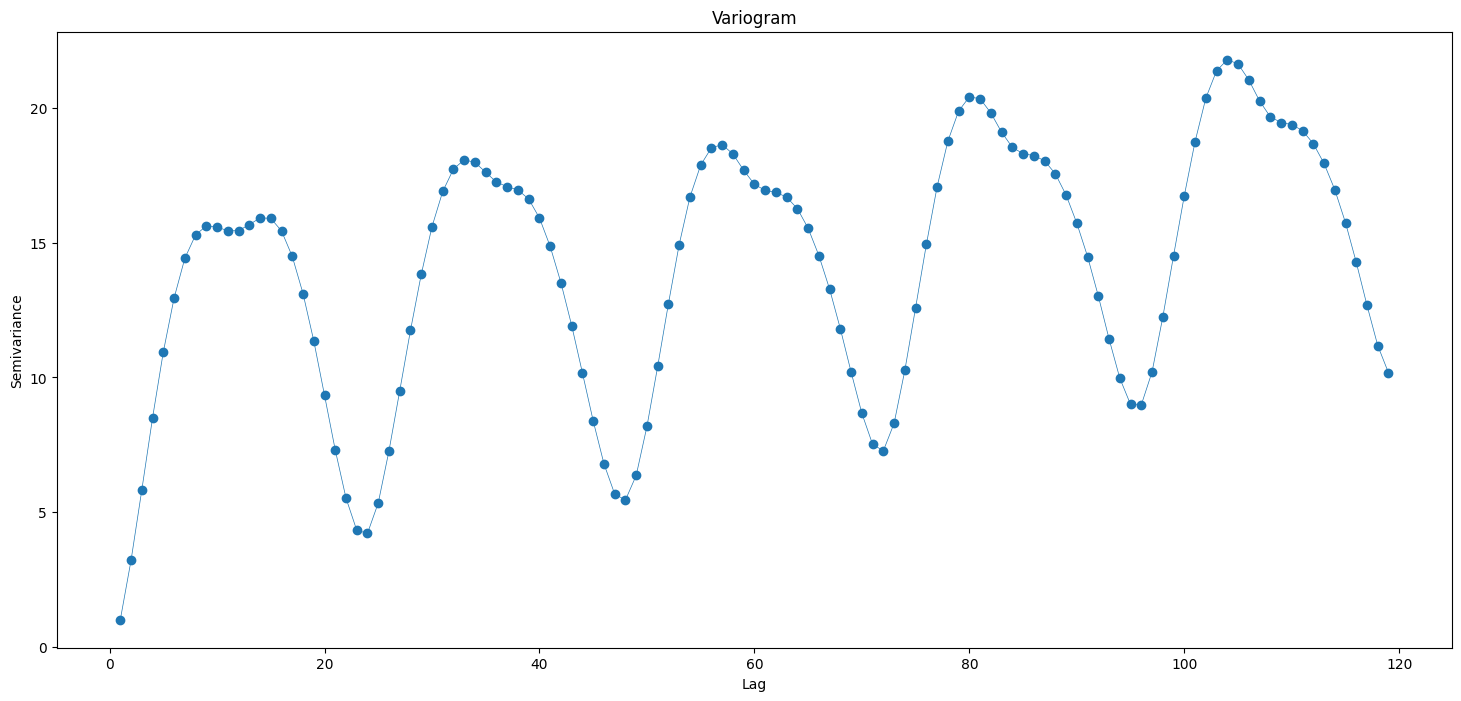

In [92]:
lags = int(len(ts_temp)/4) #quarter-length lag window for ACF visualization


# Autocorrolation Function for Temperature vs Date
plt.figure(figsize=(20,10))
ax1 = plt.subplot(111)
plot_acf(ts_temp, lags=lags, alpha=0.05, bartlett_confint=False, ax=ax1)
plt.title('Autocorrelation Function (ACF) Temperature')
plt.show()

# Autocorrolation Function for Pressure vs Date

plt.figure(figsize=(20,10))
ax1 = plt.subplot(111)
plot_acf(ts_pressure, lags=lags, alpha=0.05, bartlett_confint=False, ax=ax1)
plt.title('Autocorrelation Function (ACF) Pressure')
plt.show()

# Autocorrolation Function for Dew Point vs Date

plt.figure(figsize=(20,10))
ax1 = plt.subplot(111)
plot_acf(ts_dp, lags=lags, alpha=0.05, bartlett_confint=False, ax=ax1)
plt.title('Autocorrelation Function (ACF) Dew Point')
plt.show()


# Variograms
print("Variograms for the same time-series")
# Temperature vs Date
lags_list = range(1, lags)
variogram_temp = [np.var(ts_temp.diff(i))/np.var(ts_temp.diff(1)) for i in lags_list]
plt.figure(figsize=(18,8))
plt.plot(lags_list, variogram_temp, marker='o', linestyle='-', linewidth=0.5)
plt.xlabel('Lag')
plt.ylabel('Semivariance')
plt.title('Variogram')
plt.show()

# Pressure vs Date
lags_list = range(1, lags)
variogram_pres = [np.var(ts_pressure.diff(i))/np.var(ts_pressure.diff(1)) for i in lags_list]
plt.figure(figsize=(18,8))
plt.plot(lags_list, variogram_pres, marker='o', linestyle='-', linewidth=0.5)
plt.xlabel('Lag')
plt.ylabel('Semivariance')
plt.title('Variogram')
plt.show()

# Dew Point vs Date
lags_list = range(1, lags)
variogram_dp = [np.var(ts_dp.diff(i))/np.var(ts_dp.diff(1)) for i in lags_list]
plt.figure(figsize=(18,8))
plt.plot(lags_list, variogram_dp, marker='o', linestyle='-', linewidth=0.5)
plt.xlabel('Lag')
plt.ylabel('Semivariance')
plt.title('Variogram')
plt.show()

## Commments on the graphs

### - The first graph (Temperature vs Date) indicates that the time series has a stationary mean. However, due to the time series having a seasonal component, this indicates non-stationarity.

### - The second graph clearly shows a trend and seasonal component, thus it is non-stationary.

### - The third graph has a decaying trend with a seasonal component, making the time series non-stationary.

## 1.4 Decomposition

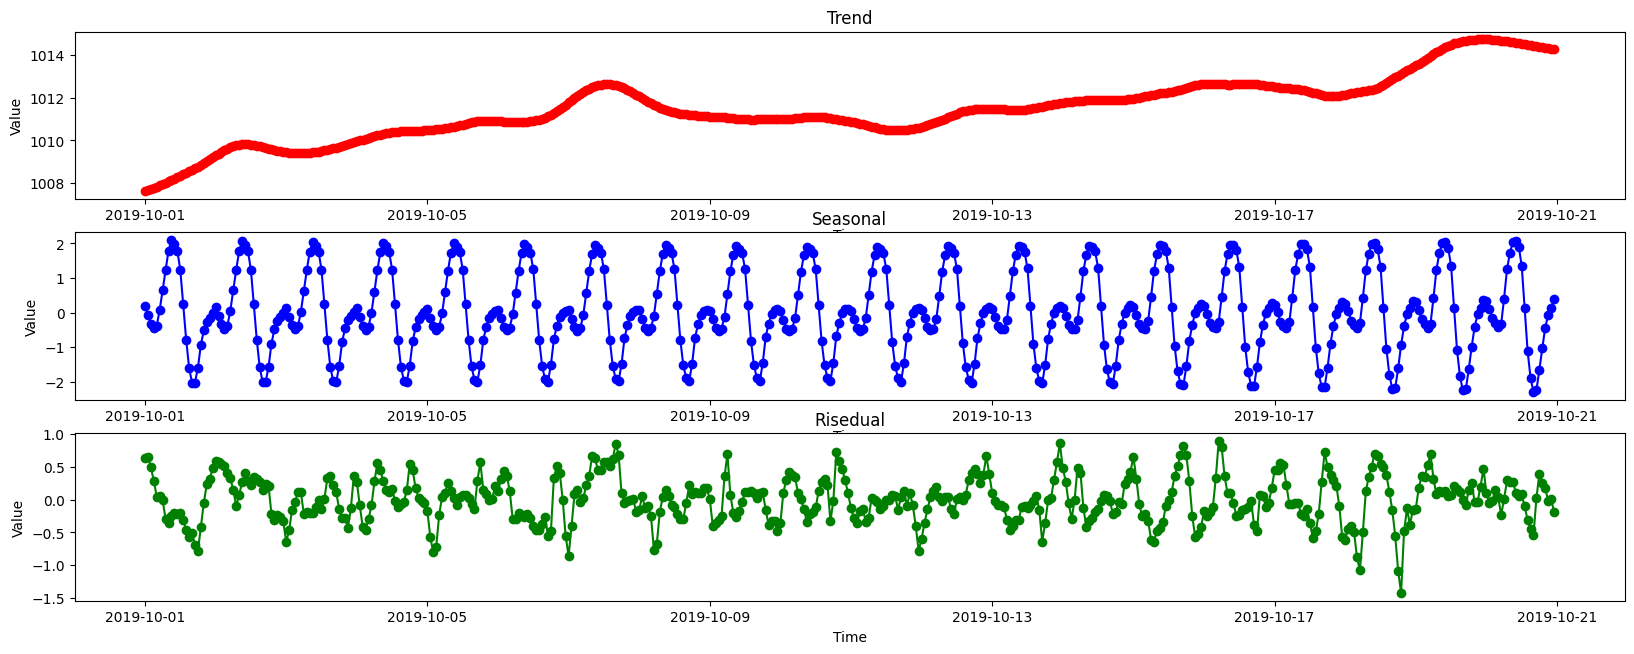

In [93]:
# Pressure decomposition
stl = STL(ts_pressure, seasonal=25) # STL requires odd positive interger for the seasonal component 
ts_decomposed = stl.fit()


plt.figure(figsize=(20, 10))

plt.subplot(4,1,2)
plt.plot(ts_decomposed.trend.index, ts_decomposed.trend.values,color='r',marker='o')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Trend')

plt.subplot(4,1,3)
plt.plot(ts_decomposed.seasonal.index, ts_decomposed.seasonal.values,color='b',marker='o')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Seasonal')

plt.subplot(4,1,4)
plt.plot(ts_decomposed.resid.index, ts_decomposed.resid.values,color='g',marker='o')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Risedual')

plt.show()

# 2. Model Development

In [94]:
# Splitting the time series (19 days for training and testing for the last day, which is the 20th of October 2019)


ts_train = ts_pressure.iloc[:456] # Size 456
ts_test = ts_pressure.iloc[456:] # Size 24


## 2.1 Exponential Smoothing (Holt-Winters Method)

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: Val

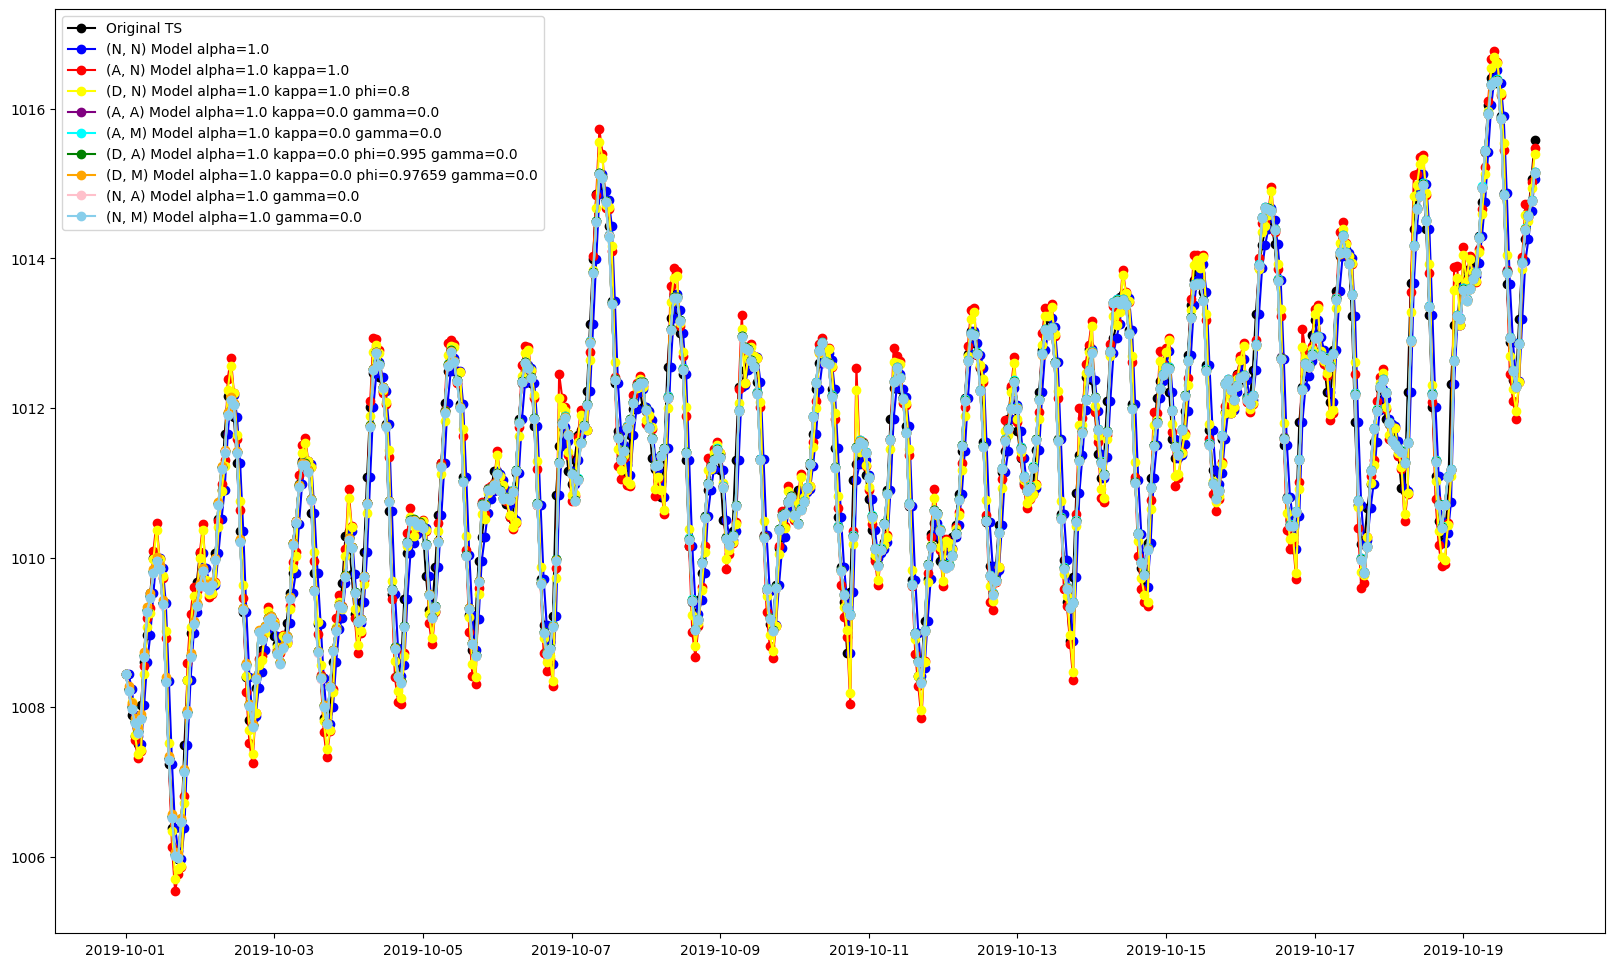

In [95]:
m = 24
fit1 = ExponentialSmoothing(ts_train, seasonal_periods=m, trend=None, seasonal=None).fit() # (N, N)
alpha1=np.round(fit1.params['smoothing_level'],5)

fit2 = ExponentialSmoothing(ts_train, trend="add", seasonal=None).fit() # (A, N)
alpha2 = np.round(fit2.params['smoothing_level'],5)
kappa2 = np.round(fit2.params['smoothing_trend'],5)


fit3 = ExponentialSmoothing(ts_train, trend="add", seasonal=None, damped_trend=True).fit() # (D, N)
alpha3 = np.round(fit3.params['smoothing_level'],5)
kappa3 = np.round(fit3.params['smoothing_trend'],5)
phi3=np.round(fit3.params['damping_trend'],5)

fit4 = ExponentialSmoothing(ts_train, seasonal_periods=m, trend='add', seasonal='add').fit() # (A, A)
alpha4=np.round(fit4.params['smoothing_level'],5)
kappa4=np.round(fit4.params['smoothing_trend'],5)
gamma4=np.round(fit4.params['smoothing_seasonal'],5)

fit5 = ExponentialSmoothing(ts_train, seasonal_periods=m, trend='add', seasonal='mul').fit() # (A, M)
alpha5=np.round(fit5.params['smoothing_level'],5)
kappa5=np.round(fit5.params['smoothing_trend'],5)
gamma5=np.round(fit5.params['smoothing_seasonal'],5)

fit6 = ExponentialSmoothing(ts_train, seasonal_periods=m, trend='add', seasonal='add', damped_trend=True).fit() # (D, A)
alpha6=np.round(fit6.params['smoothing_level'],5)
kappa6=np.round(fit6.params['smoothing_trend'],5)
gamma6=np.round(fit6.params['smoothing_seasonal'],5)
phi6=np.round(fit6.params['damping_trend'],5)

fit7 = ExponentialSmoothing(ts_train, seasonal_periods=m, trend="add", seasonal='mul', damped_trend=True).fit() # (D, M)
alpha7=np.round(fit7.params['smoothing_level'],5)
kappa7=np.round(fit7.params['smoothing_trend'],5)
gamma7=np.round(fit7.params['smoothing_seasonal'],5)
phi7=np.round(fit7.params['damping_trend'],5)

fit8 = ExponentialSmoothing(ts_train, seasonal_periods=m, trend=None, seasonal='add').fit() # (N, A)
alpha8=np.round(fit8.params['smoothing_level'],5)
gamma8=np.round(fit8.params['smoothing_seasonal'],5)

fit9 = ExponentialSmoothing(ts_train, seasonal_periods=m, trend=None, seasonal='mul').fit() # (N, M)
alpha9=np.round(fit9.params['smoothing_level'],5)
gamma9=np.round(fit9.params['smoothing_seasonal'],5)


plt.figure(figsize=(20,12))

plt.plot(ts_train,marker='o', color='black',label='Original TS')
plt.plot(fit1.fittedvalues, marker='o', color='blue', label= f'(N, N) Model alpha={alpha1}')
plt.plot(fit2.fittedvalues, marker='o', color='red', label= f'(A, N) Model alpha={alpha2} kappa={kappa2}')
plt.plot(fit3.fittedvalues, marker='o', color='yellow', label= f'(D, N) Model alpha={alpha3} kappa={kappa3} phi={phi3}')
plt.plot(fit4.fittedvalues, marker='o', color='purple', label= f'(A, A) Model alpha={alpha4} kappa={kappa4} gamma={gamma4}')
plt.plot(fit5.fittedvalues, marker='o', color='cyan', label= f'(A, M) Model alpha={alpha5} kappa={kappa5} gamma={gamma5}')
plt.plot(fit6.fittedvalues, marker='o', color='green', label= f'(D, A) Model alpha={alpha6} kappa={kappa6} phi={phi6} gamma={gamma6}')
plt.plot(fit7.fittedvalues, marker='o', color='orange', label= f'(D, M) Model alpha={alpha7} kappa={kappa7} phi={phi7} gamma={gamma7}')
plt.plot(fit8.fittedvalues, marker='o', color='pink', label= f'(N, A) Model alpha={alpha8} gamma={gamma8}')
plt.plot(fit9.fittedvalues, marker='o', color='skyblue', label= f'(N, M) Model alpha={alpha9} gamma={gamma9}')



plt.legend(loc="best")
plt.show()

In [18]:
models = {
    '(N, N) fit1': fit1.aic,
    '(A, N) fit2': fit2.aic,
    '(D, N) fit3': fit3.aic,
    '(A, A) fit4': fit4.aic,
    '(A, M) fit5': fit5.aic,
    '(D, A) fit6': fit6.aic,
    '(D, M) fit7': fit7.aic,
    '(N, A) fit8': fit8.aic,
    '(N, M) fit9': fit9.aic
}
# Sorting for better visualization
sorted_models = sorted(models.items(), key=lambda x: x[1])

print("All models ordered with their AIC values:")
for name, aic in sorted_models:
    print(f"{name}: AIC = {aic:.2f}")

# Another way to select the best three models is by doing thsi
top_3 = sorted_models[:3]

print("\nTop 3 models based on AIC:")
for i, (name, aic) in enumerate(top_3, 1):
    print(f"{i}. {name}: AIC = {aic:.2f}")

All models ordered with their AIC values:
(N, A) fit8: AIC = -1282.23
(N, M) fit9: AIC = -1282.20
(A, A) fit4: AIC = -1280.30
(A, M) fit5: AIC = -1280.25
(D, A) fit6: AIC = -1277.65
(D, M) fit7: AIC = -1276.58
(D, N) fit3: AIC = -937.99
(A, N) fit2: AIC = -882.99
(N, N) fit1: AIC = -559.86

Top 3 models based on AIC:
1. (N, A) fit8: AIC = -1282.23
2. (N, M) fit9: AIC = -1282.20
3. (A, A) fit4: AIC = -1280.30


In [19]:
fcast8 = fit8.forecast(24)
fcast9 = fit9.forecast(24)
fcast4 = fit4.forecast(24)

MSE8 = mean_squared_error(ts_test, fcast8)
MSE9 = mean_squared_error(ts_test, fcast9)
MSE4 = mean_squared_error(ts_test, fcast4)

print("MSE values:")
print(f"Fit8 (N,A): {MSE8:.4f}")
print(f"Fit9 (N,M): {MSE9:.4f}")
print(f"Fit4  (A,A): {MSE4:.4f}")


# Lowest MSE is from Fit9 (N, M)
print(f"Lowest MSE out of the three models is model 9 (N, M)")

MSE values:
Fit8 (N,A): 1.0098
Fit9 (N,M): 1.0066
Fit4  (A,A): 1.4699
Lowest MSE out of the three models is model 9 (N, M)


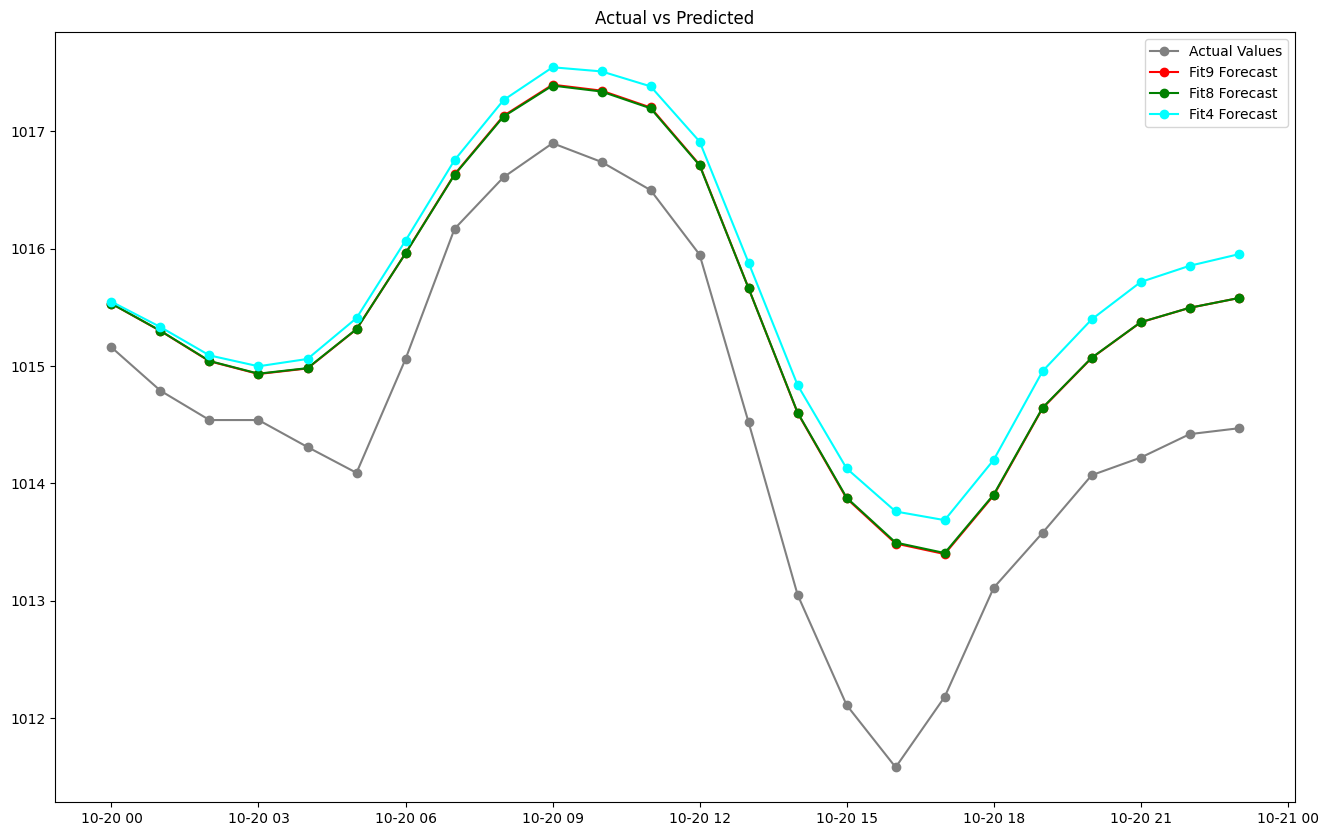

In [20]:
plt.figure(figsize=(16,10))
plt.title("Actual vs Predicted")
plt.plot(ts_test, marker="o", color="gray", label="Actual Values")
plt.plot(fcast9, marker="o", color="red", label="Fit9 Forecast")
plt.plot(fcast8, marker="o", color="green", label="Fit8 Forecast")
plt.plot(fcast4, marker="o", color="cyan", label="Fit4 Forecast")
plt.legend()
plt.show()

## 2.2 Long Short-Term Memory (LSTM) Networks

In [21]:
def time_delay_embedding(series, embedding_dimension, time_delay):
    n = len(series)
    embedding_size = n - (embedding_dimension - 1) * time_delay
    embedding = np.zeros((embedding_size, embedding_dimension))

    for i in range(embedding_size):
        for j in range(embedding_dimension):
            embedding[i, j] = series[i + j * time_delay]

    return embedding

In [22]:
# window = 5 , lstm 24 Mean Squared Error: 2.651690927386918
# window = 3 , lstm 24 Mean Squared Error: 1.3981877843380024
window = 12

X_train = time_delay_embedding(ts_train,window, 1)[:-1]
y_train = ts_train[window:]

X_test = time_delay_embedding(ts_test,window, 1)[:-1]
y_test = ts_test[window:]

print(X_train, y_train)

[[1008.45 1008.24 1007.9  ... 1010.   1009.99 1009.86]
 [1008.24 1007.9  1007.61 ... 1009.99 1009.86 1009.39]
 [1007.9  1007.61 1007.51 ... 1009.86 1009.39 1008.35]
 ...
 [1016.41 1016.52 1016.35 ... 1013.19 1013.96 1014.26]
 [1016.52 1016.35 1015.9  ... 1013.96 1014.26 1014.64]
 [1016.35 1015.9  1014.87 ... 1014.26 1014.64 1015.06]] datetime_local
2019-10-01 12:00:00    1009.39
2019-10-01 13:00:00    1008.35
2019-10-01 14:00:00    1007.24
2019-10-01 15:00:00    1006.39
2019-10-01 16:00:00    1006.08
                        ...   
2019-10-19 19:00:00    1013.96
2019-10-19 20:00:00    1014.26
2019-10-19 21:00:00    1014.64
2019-10-19 22:00:00    1015.06
2019-10-19 23:00:00    1015.58
Name: pressure, Length: 444, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_22324\2580161681.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  embedding[i, j] = series[i + j * time_delay]


In [ ]:
np.random.seed(42)


n = 100
min_mse=100
min_LSTM_pred=[]
for i in range(n):
  lstm = Sequential()
  lstm.add(Input(shape=(window,1)))
  lstm.add(LSTM(12, activation='linear'))
  lstm.add(Dense(1, activation='linear'))
  lstm.compile(loss='mean_squared_error', optimizer='adam')
  lstm.fit(X_train, y_train,epochs=50, verbose=0)
  predLSTM = lstm.predict(X_test, verbose=0)
  mse = mean_squared_error(y_test, predLSTM)
  if mse < min_mse:
    min_mse = mse
    min_LSTM_pred = predLSTM
predLSTM = min_LSTM_pred
print("Mean Squared Error:", min_mse)

Mean Squared Error: 0.6682278646722457


In [32]:
# lstm = Sequential()
# lstm.add(Input(shape=(window,1)))
# lstm.add(LSTM(12, activation='linear'))
# lstm.add(Dense(1, activation='linear'))
# lstm.compile(loss='mean_squared_error', optimizer='adam')
# lstm.fit(X_train, y_train,epochs=50, verbose=0)
# predLSTM_test = lstm.predict(X_test, verbose=0)
# mseT = mean_squared_error(y_test, predLSTM_test)
# print("Mean Squared Error:", mseT)

# 2.3 Recurrent Neural Network (RNN)

In [64]:
rnn = Sequential()
rnn.add(Input(shape=(window,1)))
rnn.add(SimpleRNN(12,activation='linear'))
rnn.add(Dense(1, activation='linear'))
rnn.compile(loss='mean_squared_error', optimizer='adam')
rnn.fit(X_train, y_train, epochs=50,verbose=0)
predRNN = rnn.predict(X_test, verbose=0)
mse = mean_squared_error(y_test, predRNN)

print("Mean Squared Error:", mse)
# Window = 2, Units = 24,  Mean Squared Error: 1.336199640584268
# Window = 2, Units = 12,  Mean Squared Error: 0.7789887659996761

Mean Squared Error: 8.597178615363354


# 4. Model Comparison
This chapter discusses the models and their performance over the time-series. That is, the comparison of the Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE) of the chosen models: Holt-Winter's & Long Short Term Memory (LSTM).



---



In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Dictionary to store results
results = {}

# Selected fits
fits = [fit4, fit8, fit9]
fit_names = ['(A, A)', '(N, A)', '(N, M)']

# Metrics
for name, fit in zip(fit_names, fits):
    y_true = ts_test
    #y_pred = fit.fittedvalues
    y_pred = fit.forecast(24)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Safe MAPE (avoids division by zero)
    epsilon = 1e-10
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    }

ESH_results_df = pd.DataFrame(results).T  # transpose to make models as rows
# print(ESH_results_df)




---



In [80]:
display(Markdown(rf"""
## Exponential Smoothing (Holt-Winters Method) Table:

| Model Name | MAE | MSE | RMSE | MAPE |
|:----------:|:---:|:---:|:----:|:----:|
| **Fit4** | {np.round(ESH_results_df.MAE.iloc[0],5)} | {np.round(ESH_results_df.MSE.iloc[0],5)} | {np.round(ESH_results_df.RMSE.iloc[0],5)} | {np.round(ESH_results_df.MAPE.iloc[0],5)} |
| **Fit8** | {np.round(ESH_results_df.MAE.iloc[1],5)} | {np.round(ESH_results_df.MSE.iloc[1],5)} | {np.round(ESH_results_df.RMSE.iloc[1],5)} | {np.round(ESH_results_df.MAPE.iloc[1],5)} |
| **Fit9** | {np.round(ESH_results_df.MAE.iloc[2],5)} | {np.round(ESH_results_df.MSE.iloc[2],5)} | {np.round(ESH_results_df.RMSE.iloc[2],5)} | {np.round(ESH_results_df.MAPE.iloc[2],5)} |
"""))


## Exponential Smoothing (Holt-Winters Method) Table:

| Model Name | MAE | MSE | RMSE | MAPE |
|:----------:|:---:|:---:|:----:|:----:|
| **Fit4** | 1.10818 | 1.46991 | 1.2124 | 0.10928 |
| **Fit8** | 0.91327 | 1.00981 | 1.00489 | 0.09007 |
| **Fit9** | 0.91279 | 1.00661 | 1.0033 | 0.09002 |


In [59]:
display(Markdown(rf"""
## MSEs:
### Fit9 (N,M): **{np.round(ESH_results_df.MSE.iloc[2],5)}**
### Fit8 (N,A): **{np.round(ESH_results_df.MSE.iloc[1],5)}**
### Fit4 (A,A): **{np.round(ESH_results_df.MSE.iloc[0],5)}**
"""))


## MSEs:
### Fit9 (N,M): **1.00661**
### Fit8 (N,A): **1.00981**
### Fit4 (A,A): **1.46991**


In [81]:
# Metrics
LSTM_mse = mean_squared_error(y_test, predLSTM)
LSTM_mae = mean_absolute_error(y_test, predLSTM)
LSTM_rmse = np.sqrt(mse)
epsilon = 1e-10
predLSTM_flat = predLSTM.flatten() ## Flatten to calculate MAPE
LSTM_mape = np.mean(np.abs((y_test - predLSTM_flat) / (y_test + epsilon))) * 100

# Results
# print(f"LSTM Metrics:")
# print(f"MAE:  {LSTM_mae:.5f}")
# print(f"MSE:  {LSTM_mse:.5f}")
# print(f"RMSE: {LSTM_rmse:.5f}")
# print(f"MAPE: {LSTM_mape:.5f}%")

In [62]:
display(Markdown(rf"""
## Long Short Term memory (LSTM) Table:

| Model Name | MAE | MSE | RMSE | MAPE |
|:----------:|:---:|:---:|:----:|:----:|
| **LSTM** | {np.round(LSTM_mae,5)} | {np.round(LSTM_mse,5)} | {np.round(LSTM_rmse,5)} | {np.round(LSTM_mape,5)} |
"""))


## Long Short Term memory (LSTM) Table:

| Model Name | MAE | MSE | RMSE | MAPE |
|:----------:|:---:|:---:|:----:|:----:|
| **LSTM** | 0.56661 | 0.66823 | 1.0033 | 0.05592 |




---



# Recurrent Neural Network Table:

In [82]:
# Metrics
RNN_mse = mean_squared_error(y_test, predRNN)
RNN_mae = mean_absolute_error(y_test, predRNN)
RNN_rmse = np.sqrt(mse)
epsilon = 1e-10
predRNN_flat = predRNN.flatten() ## Flatten to calculate MAPE
RNN_mape = np.mean(np.abs((y_test - predRNN_flat) / (y_test + epsilon))) * 100

# Results
# print(f"RNN Metrics:")
# print(f"MAE:  {RNN_mae:.5f}")
# print(f"MSE:  {RNN_mse:.5f}")
# print(f"RMSE: {RNN_rmse:.5f}")
# print(f"MAPE: {RNN_mape:.5f}%")

In [78]:
display(Markdown(rf"""
## Recurrent Neural Network (RNN) Table:

| Model Name | MAE | MSE | RMSE | MAPE |
|:----------:|:---:|:---:|:----:|:----:|
| **RNN** | {np.round(RNN_mae,5)} | {np.round(RNN_mse,5)} | {np.round(RNN_rmse,5)} | {np.round(RNN_mape,5)} |
"""))


## Recurrent Neural Network (RNN) Table:

| Model Name | MAE | MSE | RMSE | MAPE |
|:----------:|:---:|:---:|:----:|:----:|
| **RNN** | 2.56123 | 8.59718 | 2.93209 | 0.25269 |


## Plot of Comparison

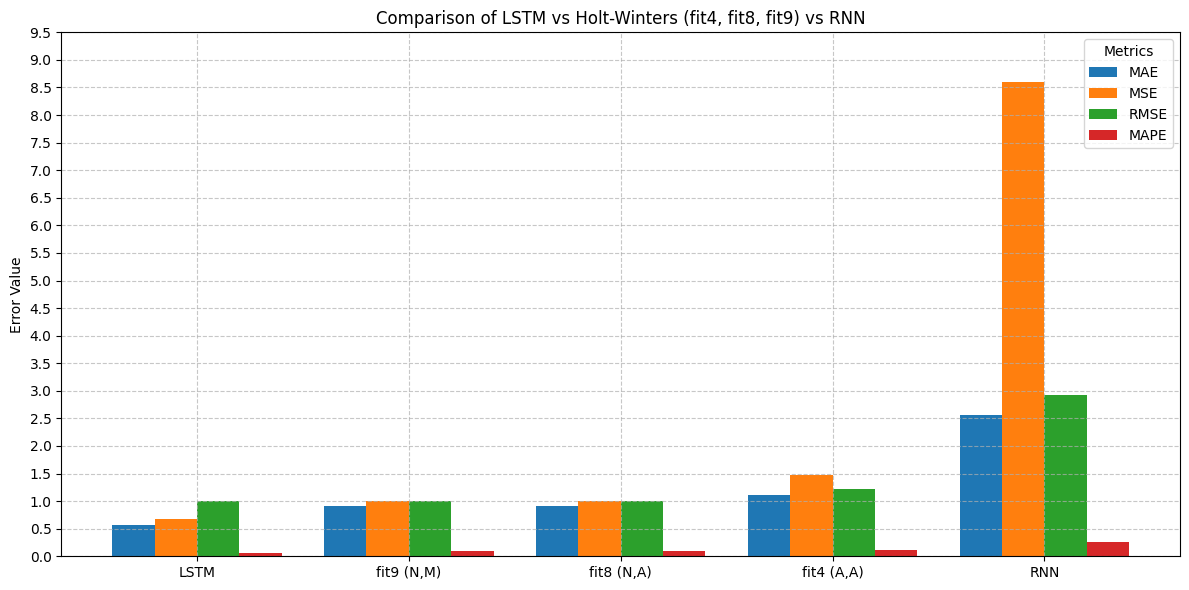

In [76]:
data = {
    'LSTM': [LSTM_mae, LSTM_mse, LSTM_rmse, LSTM_mape],
    'fit9 (N,M)': [ESH_results_df.MAE.iloc[2], ESH_results_df.MSE.iloc[2], ESH_results_df.RMSE.iloc[2], ESH_results_df.MAPE.iloc[2]],
    'fit8 (N,A)': [ESH_results_df.MAE.iloc[1], ESH_results_df.MSE.iloc[1], ESH_results_df.RMSE.iloc[1], ESH_results_df.MAPE.iloc[1]],
    'fit4 (A,A)': [ESH_results_df.MAE.iloc[0], ESH_results_df.MSE.iloc[0], ESH_results_df.RMSE.iloc[0], ESH_results_df.MAPE.iloc[0]],
    'RNN': [RNN_mae, RNN_mse, RNN_rmse, RNN_mape]
}

metrics = ['MAE', 'MSE', 'RMSE', 'MAPE']

df = pd.DataFrame(data, index=metrics)

x = np.arange(len(data))  # label locations
width = 0.2  # width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width - width*1.5, df.loc[metric], width, label=metric)

# Labels and Title
ax.set_ylabel('Error Value')
ax.set_title('Comparison of LSTM vs Holt-Winters (fit4, fit8, fit9) vs RNN')
ax.set_xticks(x)
ax.set_xticklabels(df.columns)
ax.legend(title='Metrics')

plt.yticks(np.arange(0, 10, 0.5))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
